In [88]:
import pandas as pd
from tqdm import tqdm
import numpy as np

In [89]:
path_file = './data/sdc_viti_magasin_tableau_de_bord_can.csv'


df = {}

In [90]:
df['sdc_viti'] = pd.read_csv(path_file, dtype={'nom_departement': str})

In [91]:
shapefile = '../../../02_outils/data/external_data/geospatial_data/geoVec_oldreg.json'
gdf_regions = gpd.read_file(shapefile)

In [92]:
df['sdc_viti'].loc[
    df['sdc_viti']['nom_departement'] == '07'
]

,id_code_dephy_campagne,sdc_code_dephy,campagne_donnees,sdc_valide,dispositif_type,reseaux_it,reseau_ir,domaine_id,domaine_nom,numero_departement,...,co_reelles_irrig_sdc,co_reelles_semences_sdc,co_reelles_autres_sdc,co_reelles_lutte_bio_sdc,situation_production_mill,codes_convention_dephy,rec_moyens_biologiques_sdc,recours_macroorganismes_sdc,recours_pdts_biot_sansamm_sdc,recours_ptds_abiot_sansamm_sdc
24,VIF36937_2018,VIF36937,2018,oui,DEPHY_FERME,IT_POIROT,IR_GUIGOU,fr.inra.agrosyst.api.entities.Domain_1c4d3f54-...,G-Mauv,7,...,0.0,0.0,0.0,315.859970,Agriculture biologique_Vallée-du-Rhône-Provenc...,16CA07VI,0.0,0.0,0.0,0.0
40,VIF34410_2016,VIF34410,2016,oui,DEPHY_FERME,IT_POIROT,IR_BONNEFOUX,fr.inra.agrosyst.api.entities.Domain_d490e9cc-...,07BOURG SAINT ANDEOL,7,...,0.0,0.0,0.0,269.124758,Agriculture biologique_Vallée-du-Rhône-Provenc...,87CA07VI,0.0,0.0,0.0,0.0
53,VIF33646_2018,VIF33646,2018,oui,DEPHY_FERME,IT_POIROT,IR_BONNEFOUX,fr.inra.agrosyst.api.entities.Domain_2e33df1d-...,07LABLACHERE,7,...,0.0,0.0,0.0,519.219468,Agriculture conventionnelle_Vallée-du-Rhône-Pr...,87CA07VI,0.0,0.0,0.0,0.0
102,VIF59521_2025,VIF59521,2025,oui,DEPHY_FERME,IT_POIROT,IR_GUIGOU,fr.inra.agrosyst.api.entities.Domain_d39928ae-...,M-Luy,7,...,0.0,0.0,0.0,515.502441,Agriculture biologique_Vallée-du-Rhône-Provenc...,16CA07VI,5.0,0.0,5.0,0.0
104,VIF35236_2022,VIF35236,2022,non,DEPHY_FERME,IT_POIROT,IR_GUIGOU,fr.inra.agrosyst.api.entities.Domain_7b2785d9-...,G-Glun,7,...,0.0,0.0,0.0,143.321776,Agriculture biologique_Vallée-du-Rhône-Provenc...,16CA07VI,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7524,VIF10053_2020,VIF10053,2020,non,DEPHY_FERME,IT_POIROT,IR_BONNEFOUX,fr.inra.agrosyst.api.entities.Domain_9632bfcc-...,07VALVIGNERES,7,...,0.0,0.0,0.0,316.207356,Agriculture conventionnelle_Vallée-du-Rhône-Pr...,87CA07VI,0.0,0.0,0.0,0.0
7535,VIF10805_2019,VIF10805,2019,non,DEPHY_FERME,IT_POIROT,IR_BONNEFOUX,fr.inra.agrosyst.api.entities.Domain_7a1101ba-...,07MIRABEL,7,...,0.0,0.0,0.0,237.102066,Agriculture biologique_Vallée-du-Rhône-Provenc...,87CA07VI,0.0,0.0,0.0,0.0
7564,VIF34651_2017,VIF34651,2017,oui,DEPHY_FERME,IT_POIROT,IR_GUIGOU,fr.inra.agrosyst.api.entities.Domain_fa70be94-...,D-StJean,7,...,0.0,0.0,0.0,200.989398,Agriculture conventionnelle_Vallée-du-Rhône-Pr...,16CA07VI,0.0,0.0,0.0,0.0
7606,VIF33225_2023,VIF33225,2023,non,DEPHY_FERME,IT_POIROT,IR_GUIGOU,fr.inra.agrosyst.api.entities.Domain_ecca3863-...,D-Sarr,7,...,0.0,0.0,0.0,290.307498,Agriculture conventionnelle_Vallée-du-Rhône-Pr...,16CA07VI,0.0,0.0,0.0,0.0


In [101]:
df_ift = df['sdc_viti'][['ift_chimique_moyen_ssp', 'ift_norme', 'nom_departement']].loc[
    df['sdc_viti']['campagne_donnees'] == STUDIED_CAMPAGNE
]

,ift_norme
nom_departement,
02,NaN
07,0.678050
10,0.421560
11,0.850742
13,0.498380
16,0.505666
17,0.508137
21,0.560742
24,0.474792


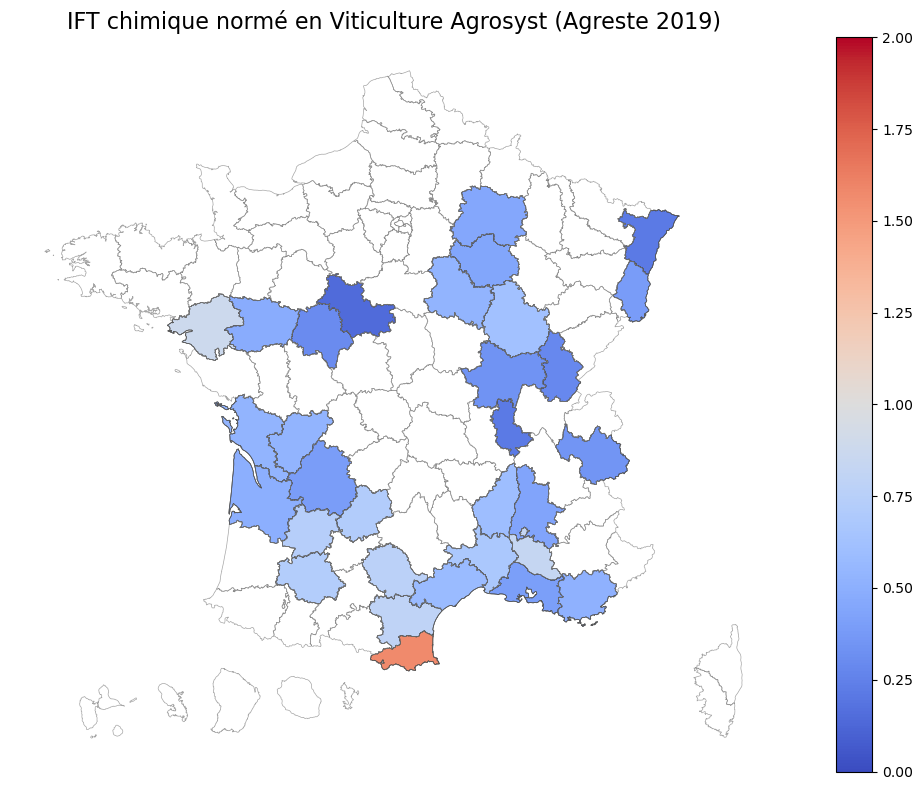

In [113]:
# -*- coding: utf-8 -*-
"""
Code généré grace à ARGO, 11 septembre 2026
"""

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

STUDIED_CAMPAGNE = 2019

# ------------------------------------------------------------------
# 1. Charger le DataFrame d’IFT
# ------------------------------------------------------------------
# Exemple de chargement depuis un CSV
# df_ift = pd.read_csv('ift_par_region.csv')  # <-- à adapter

# Pour rester générique, on crée un DataFrame fictif (conseil : supprime cette partie quand tu ais ton fichier)
df_ift = df['sdc_viti'][['ift_chimique_moyen_ssp', 'ift_norme', 'nom_departement']].loc[
    df['sdc_viti']['campagne_donnees'] == STUDIED_CAMPAGNE
]
df_ift = df_ift.groupby('nom_departement').agg({
    'ift_norme' : 'median'
})
# ------------------------------------------------------------------
# 2. Charger le fichier géométrique des anciennes régions
# ------------------------------------------------------------------
# Remplace le chemin par celui de ton fichier shapefile / geojson
# Par exemple : shapefile = 'ancienne_regions_france.shp'
shapefile = '../../../02_outils/data/external_data/geospatial_data/geoVec_dep.json'
gdf_regions = gpd.read_file(shapefile)
gdf_regions['Department_code_name'] = gdf_regions['Department_code_name'].str.split(' - ').apply(lambda x : x[0]).astype('str')

# gdf_regions.loc[
#     gdf_regions['Region_old'] == 'Centre-Val de Loire', 'Region_old'
# ] = 'Centre'

# ------------------------------------------------------------------
# 4. Fusionner les deux jeux
# ------------------------------------------------------------------
gdf_merged = gdf_regions.merge(df_ift, left_on='Department_code_name', right_on='nom_departement', how='left')

# Si certaines régions ne trouvent pas d’IFT, elles devront
# être inspectées ou précisées (ex : valider les noms, ajouter des
# valeurs NA, etc.)


# ------------------------------------------------------------------
# 5. Visualiser
# ------------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
# On masque les frontières extérieures pour une meilleure lisibilité
gdf_merged.boundary.plot(ax=ax, linewidth=0.5, color='grey', alpha=0.7)

# Petite option supplémentaire : rendre les polygones transparents
#gdf_merged.plot(column='ift',
#                cmap='viridis',  # ou 'plasma', 'coolwarm', ...
#                linewidth=0.5,
#                edgecolor='black',
#                legend=True,
#                ax=ax,
#                alpha=0.8)    # pour voir les frontières

# Ici on décide d’un rendu complet (sans alpha) :
norm = TwoSlopeNorm(vcenter=1, vmin=0, vmax=2)

gdf_merged.plot(column='ift_norme',
                cmap='coolwarm',
                norm=norm,
                linewidth=0.5,
                edgecolor='black',
                legend=True,
                ax=ax)

ax.set_title('IFT chimique normé en Viticulture Agrosyst (Agreste '+str(STUDIED_CAMPAGNE)+')', fontsize=16)
ax.axis('off')

fichier = 'ift_ancienne_regions_'+str(STUDIED_CAMPAGNE)+'.png'
plt.savefig(fichier,
            dpi=300,                # résolution (300→qualité print, 72→web)
            bbox_inches='tight',    # enlève les marges blanches
            transparent=False)      # false pour un fond blanc


plt.tight_layout()
plt.show()



In [100]:
gdf_merged.iloc[39]

Department_code_name                                                     11
geometry                  POLYGON ((2.8947931029651857 43.32623344227455...
ift_chimique_moyen_ssp                                                 11.1
ift_norme                                                               NaN
nom_departement                                                          11
Name: 39, dtype: object

In [94]:
df['sdc_viti']['ift_tota']

KeyError: 'ift_tota'

,ift_chimique_moyen_ssp,ift_norme,nom_departement
0,NaN,NaN,66
1,13.0,0.310554,49
2,NaN,NaN,32
3,11.4,0.087719,13
4,NaN,NaN,33
...,...,...,...
7599,NaN,NaN,81
7600,NaN,NaN,89
7601,NaN,NaN,86
7602,NaN,NaN,16
